## Data Loading and Initial Inspection

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Check Unique Target Values

In [ ]:
df["target"].nunique()

3

## Display Unique Target Values

In [ ]:
print(df["target"].unique())


[0 1 2]


## Prepare Features (X) and Target (y)

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (178, 13)
y shape: (178,)


## Train a Decision Tree Model (max_depth=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=1, random_state=42)

tree.fit(X,y)

DecisionTreeClassifier(max_depth=1, random_state=42)

## Visualize Decision Tree (max_depth=1)

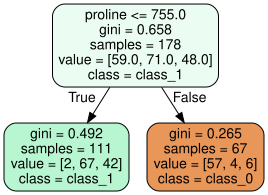

In [ ]:
from graphviz import Source
from sklearn.tree import export_graphviz
import os
image_path = '/content'

export_graphviz(
    tree,
    out_file=os.path.join(image_path, 'wine.dot'),
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    rounded=True,
    filled=True
)

# To display the graph in the notebook:
Source.from_file(os.path.join(image_path, 'wine.dot'))

## Train and Visualize Decision Trees (max_depth=2 and 3)


--- Decision Tree with max_depth=2 ---


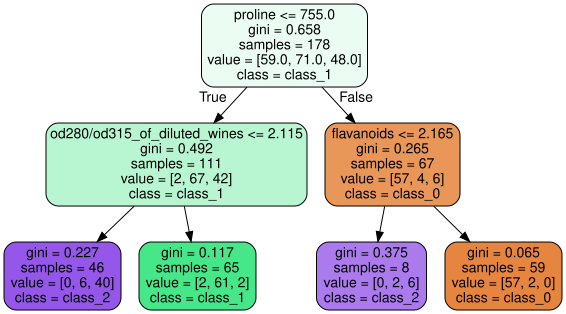


--- Decision Tree with max_depth=3 ---


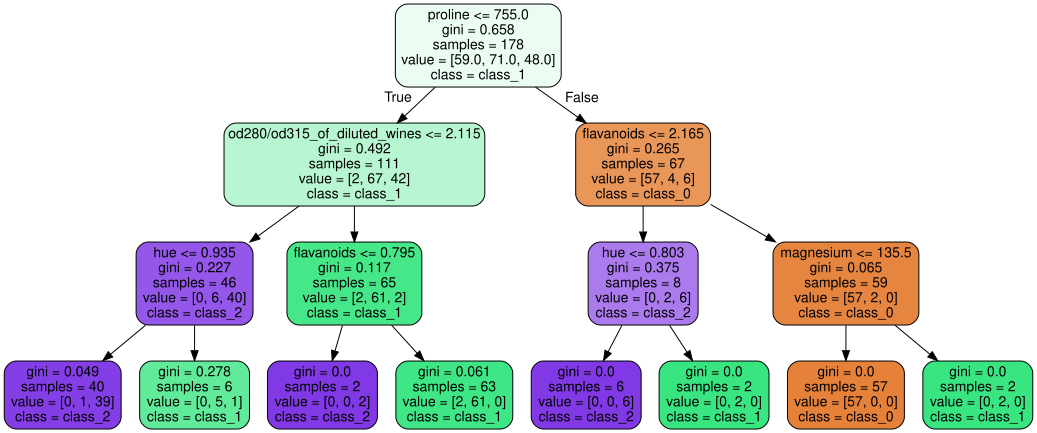

In [ ]:
depths = [2, 3]
image_path = '/content'

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X, y)

    dot_filename = f'wine_depth_{d}.dot'
    export_graphviz(
        model,
        out_file=os.path.join(image_path, dot_filename),
        feature_names=wine.feature_names,
        class_names=wine.target_names,
        rounded=True,
        filled=True
    )

    print(f'\n--- Decision Tree with max_depth={d} ---')
    display(Source.from_file(os.path.join(image_path, dot_filename)))

## Visualize Decision Boundary of Decision Tree

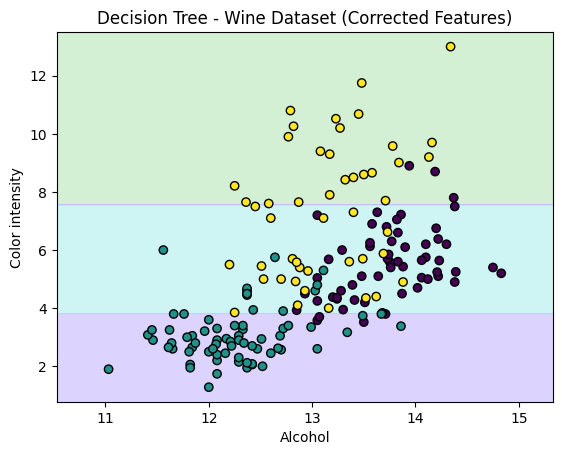

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier

X_full = wine.data
X_2d = X_full[:, [0, 9]]
y_vis = wine.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_2d, y_vis)

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_background = ListedColormap(["#aeeeee", "#c5b8ff", "#b8e6b8"])
plt.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_background)

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_vis,
    cmap="viridis",
    edgecolor="black"
)

plt.xlabel("Alcohol")
plt.ylabel("Color intensity")
plt.title("Decision Tree - Wine Dataset (Corrected Features)")
plt.show()